<a href="https://colab.research.google.com/github/Skylar3017/UCV_ATE_SI_LAB013/blob/develop/Laboratorio_13_UCV_RNN_Traductor_Ruso.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
%pip install tensorflow pandas numpy -q

In [29]:
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Embedding, Dense

tf.random.set_seed(42)
np.random.seed(42)

print('TensorFlow:', tf.__version__)

TensorFlow: 2.20.0


In [30]:
translation_pairs = [
    ('привет', 'hola'),
    ('здравствуй', 'hola'),
    ('доброе утро', 'buenos días'),
    ('добрый день', 'buenas tardes'),
    ('добрый вечер', 'buenas noches'),
    ('спокойной ночи', 'buenas noches'),
    ('спасибо', 'gracias'),
    ('большое спасибо', 'muchas gracias'),
    ('пожалуйста', 'por favor'),
    ('извини', 'lo siento'),
    ('как дела', 'cómo estás'),
    ('я хорошо', 'estoy bien'),
    ('я плохо', 'estoy mal'),
    ('я устал', 'estoy cansado'),
    ('я голоден', 'tengo hambre'),
    ('я хочу воды', 'quiero agua'),
    ('я хочу есть', 'quiero comer'),
    ('где туалет', 'dónde está el baño'),
    ('сколько стоит', 'cuánto cuesta'),
    ('это дорого', 'esto es caro'),
    ('это дешево', 'esto es barato'),
    ('я студент', 'soy estudiante'),
    ('я преподаватель', 'soy profesor'),
    ('я из перу', 'soy de perú'),
    ('ты говоришь по испански', 'hablas español'),
    ('я говорю по русски', 'hablo ruso'),
    ('я не понимаю', 'no entiendo'),
    ('повтори пожалуйста', 'repite por favor'),
    ('я тебя люблю', 'te quiero'),
    ('я скучаю по тебе', 'te extraño'),
    ('до свидания', 'adiós'),
    ('увидимся завтра', 'nos vemos mañana'),
    ('сегодня холодно', 'hoy hace frío'),
    ('сегодня жарко', 'hoy hace calor'),
    ('мне нравится музыка', 'me gusta la música'),
    ('мне нравится кофе', 'me gusta el café'),
    ('я люблю читать', 'me gusta leer'),
    ('я люблю путешествовать', 'me gusta viajar'),
    ('это мой друг', 'este es mi amigo'),
    ('это моя подруга', 'esta es mi amiga'),
    ('у меня есть вопрос', 'tengo una pregunta'),
    ('помоги мне', 'ayúdame'),
    ('открой дверь', 'abre la puerta'),
    ('закрой дверь', 'cierra la puerta'),
    ('я дома', 'estoy en casa'),
    ('я в университете', 'estoy en la universidad'),
    ('я работаю', 'estoy trabajando'),
    ('я учусь', 'estoy estudiando'),
    ('мне нужно идти', 'tengo que irme'),
    ('до завтра', 'hasta mañana'),
    ('добро пожаловать', 'bienvenido'),
    ('приятно познакомиться', 'mucho gusto'),
    ('как тебя зовут', 'cómo te llamas'),
    ('меня зовут анна', 'me llamo ana'),
    ('где автобус', 'dónde está el autobús'),
    ('где вокзал', 'dónde está la estación'),
    ('я хочу кофе', 'quiero café'),
    ('я хочу чай', 'quiero té'),
    ('мне нравится спорт', 'me gusta el deporte'),
    ('я люблю собак', 'me gustan los perros'),
    ('я люблю кошек', 'me gustan los gatos'),
    ('сколько времени', 'qué hora es'),
    ('я счастлив', 'estoy feliz'),
    ('мне грустно', 'estoy triste'),
    ('это очень хорошо', 'esto está muy bien'),
    ('это очень плохо', 'esto está muy mal'),
    ('до скорого', 'hasta pronto'),
    ('удачи', 'buena suerte'),
    ('я понимаю', 'entiendo'),
    ('приятного аппетита', 'buen provecho'),
]

df = pd.DataFrame(translation_pairs, columns=['ruso', 'espanol'])
df.head(10)

,ruso,espanol
0,привет,hola
1,здравствуй,hola
2,доброе утро,buenos días
3,добрый день,buenas tardes
4,добрый вечер,buenas noches
5,спокойной ночи,buenas noches
6,спасибо,gracias
7,большое спасибо,muchas gracias
8,пожалуйста,por favor
9,извини,lo siento


In [31]:
df['target_input'] = '<start> ' + df['espanol']
df['target_output'] = df['espanol'] + ' <end>'

df.head()

,ruso,espanol,target_input,target_output
0,привет,hola,<start> hola,hola <end>
1,здравствуй,hola,<start> hola,hola <end>
2,доброе утро,buenos días,<start> buenos días,buenos días <end>
3,добрый день,buenas tardes,<start> buenas tardes,buenas tardes <end>
4,добрый вечер,buenas noches,<start> buenas noches,buenas noches <end>


In [32]:
input_tokenizer = Tokenizer(filters='')
input_tokenizer.fit_on_texts(df['ruso'])

target_tokenizer = Tokenizer(filters='')
target_tokenizer.fit_on_texts(pd.concat([df['target_input'], df['target_output']]))

input_sequences = input_tokenizer.texts_to_sequences(df['ruso'])
target_input_sequences = target_tokenizer.texts_to_sequences(df['target_input'])
target_output_sequences = target_tokenizer.texts_to_sequences(df['target_output'])

print('Ejemplo ruso tokenizado:', input_sequences[0])
print('Ejemplo español entrada tokenizado:', target_input_sequences[0])
print('Ejemplo español salida tokenizado:', target_output_sequences[0])

Ejemplo ruso tokenizado: [27]
Ejemplo español entrada tokenizado: [1, 17]
Ejemplo español salida tokenizado: [17, 2]


In [33]:
max_encoder_seq_length = max(len(seq) for seq in input_sequences)
max_decoder_seq_length = max(len(seq) for seq in target_input_sequences)

encoder_input_data = pad_sequences(
    input_sequences,
    maxlen=max_encoder_seq_length,
    padding='post'
)

decoder_input_data = pad_sequences(
    target_input_sequences,
    maxlen=max_decoder_seq_length,
    padding='post'
)

decoder_target_data = pad_sequences(
    target_output_sequences,
    maxlen=max_decoder_seq_length,
    padding='post'
)

num_encoder_tokens = len(input_tokenizer.word_index) + 1
num_decoder_tokens = len(target_tokenizer.word_index) + 1

print('Longitud máxima encoder:', max_encoder_seq_length)
print('Longitud máxima decoder:', max_decoder_seq_length)
print('Vocabulario ruso:', num_encoder_tokens)
print('Vocabulario español:', num_decoder_tokens)

Longitud máxima encoder: 4
Longitud máxima decoder: 5
Vocabulario ruso: 99
Vocabulario español: 108


In [34]:
decoder_target_data = np.expand_dims(decoder_target_data, -1)
decoder_target_data.shape

(70, 5, 1)

In [35]:
embedding_dim = 64
latent_dim = 128

# Encoder
encoder_inputs = Input(shape=(None,), name='encoder_inputs')
encoder_embedding = Embedding(
    input_dim=num_encoder_tokens,
    output_dim=embedding_dim,
    mask_zero=True,
    name='encoder_embedding'
)(encoder_inputs)

encoder_lstm = LSTM(latent_dim, return_state=True, name='encoder_lstm')
_, state_h, state_c = encoder_lstm(encoder_embedding)
encoder_states = [state_h, state_c]

# Decoder
decoder_inputs = Input(shape=(None,), name='decoder_inputs')
decoder_embedding_layer = Embedding(
    input_dim=num_decoder_tokens,
    output_dim=embedding_dim,
    mask_zero=True,
    name='decoder_embedding'
)
decoder_embedding = decoder_embedding_layer(decoder_inputs)

decoder_lstm = LSTM(
    latent_dim,
    return_sequences=True,
    return_state=True,
    name='decoder_lstm'
)
decoder_outputs, _, _ = decoder_lstm(decoder_embedding, initial_state=encoder_states)

decoder_dense = Dense(num_decoder_tokens, activation='softmax', name='decoder_dense')
decoder_outputs = decoder_dense(decoder_outputs)

model = Model([encoder_inputs, decoder_inputs], decoder_outputs)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_inputs      │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_inputs      │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, None, 64)  │      6,336 │ encoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_6         │ (None, None)      │          0 │ encoder_inputs[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, None, 64)  │      6,912 │ decoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 128),     │     98,816 │ encoder_embeddin… │
│                     │ (None, 128),      │            │ not_equal_6[0][0] │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, None,     │     98,816 │ decoder_embeddin… │
│                     │ 128), (None,      │            │ encoder_lstm[0][… │
│                     │ 128), (None,      │            │ encoder_lstm[0][… │
│                     │ 128)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_dense       │ (None, None, 108) │     13,932 │ decoder_lstm[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 224,812 (878.17 KB)

 Trainable params: 224,812 (878.17 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
history = model.fit(
    [encoder_input_data, decoder_input_data],
    decoder_target_data,
    batch_size=8,
    epochs=300,
    validation_split=0.2,
    verbose=0
)

print('Entrenamiento finalizado.')

Entrenamiento finalizado.


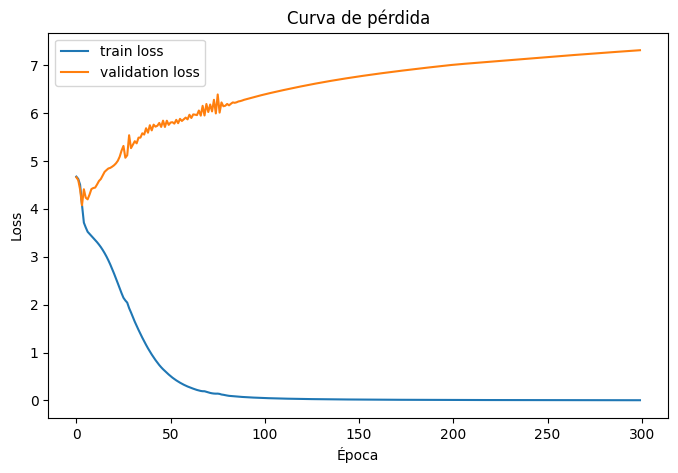

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.title('Curva de pérdida')
plt.legend()
plt.show()

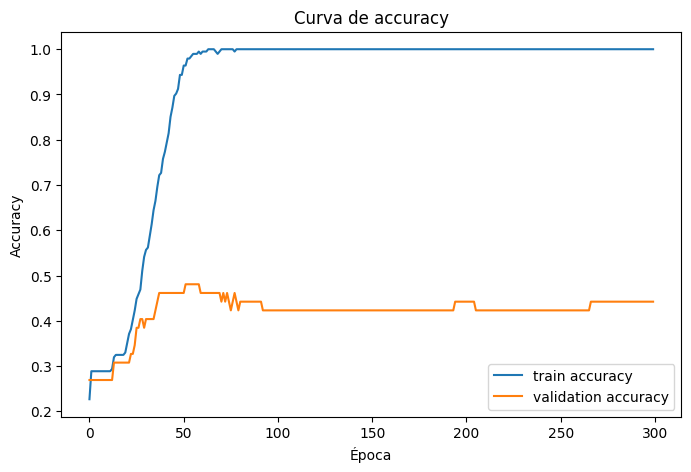

In [38]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.title('Curva de accuracy')
plt.legend()
plt.show()

In [39]:
# Modelo encoder para inferencia
encoder_model = Model(encoder_inputs, encoder_states)

# Modelo decoder para inferencia
decoder_state_input_h = Input(shape=(latent_dim,), name='decoder_state_input_h')
decoder_state_input_c = Input(shape=(latent_dim,), name='decoder_state_input_c')
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

decoder_inputs_single = Input(shape=(1,), name='decoder_input_single')
decoder_embedding_single = decoder_embedding_layer(decoder_inputs_single)

decoder_outputs_single, state_h_single, state_c_single = decoder_lstm(
    decoder_embedding_single,
    initial_state=decoder_states_inputs
)
decoder_states_single = [state_h_single, state_c_single]
decoder_outputs_single = decoder_dense(decoder_outputs_single)

decoder_model = Model(
    [decoder_inputs_single] + decoder_states_inputs,
    [decoder_outputs_single] + decoder_states_single
)

In [40]:
reverse_target_word_index = {
    index: word for word, index in target_tokenizer.word_index.items()
}

start_token = target_tokenizer.word_index['<start>']
end_token = target_tokenizer.word_index['<end>']


def translate(sentence):
    sequence = input_tokenizer.texts_to_sequences([sentence])
    sequence = pad_sequences(
        sequence,
        maxlen=max_encoder_seq_length,
        padding='post'
    )

    states_value = encoder_model.predict(sequence, verbose=0)

    target_sequence = np.array([[start_token]])
    translated_words = []

    for _ in range(max_decoder_seq_length):
        output_tokens, h, c = decoder_model.predict(
            [target_sequence] + states_value,
            verbose=0
        )

        sampled_token_index = np.argmax(output_tokens[0, -1, :])

        if sampled_token_index == end_token:
            break

        sampled_word = reverse_target_word_index.get(sampled_token_index, '')

        if sampled_word:
            translated_words.append(sampled_word)

        target_sequence = np.array([[sampled_token_index]])
        states_value = [h, c]

    return ' '.join(translated_words)

In [42]:
test_sentences = [
    'добро пожаловать',
    'приятно познакомиться',
    'как тебя зовут',
    'я хочу кофе',
    'я люблю кошек',
    'удачи',
]

for sentence in test_sentences:
    print(f'{sentence}  ->  {translate(sentence)}')

добро пожаловать  ->  bienvenido
приятно познакомиться  ->  mucho gusto
как тебя зовут  ->  cómo te llamas
я хочу кофе  ->  quiero comer
я люблю кошек  ->  me gusta
удачи  ->  lo siento


In [43]:
new_sentences = [
    'я люблю чай',
    'ты мой друг',
    'добрый вечер друг',
    'я счастлив сегодня',
    'мне нравится читать',
]

for sentence in new_sentences:
    print(f'{sentence}  ->  {translate(sentence)}')

я люблю чай  ->  me gusta
ты мой друг  ->  tengo que
добрый вечер друг  ->  buenas noches
я счастлив сегодня  ->  soy entiendo
мне нравится читать  ->  me gusta el café


In [44]:
model.save('russian_spanish_seq2seq_lstm_extended.keras')
print('Modelo guardado como russian_spanish_seq2seq_lstm_extended.keras')

Modelo guardado como russian_spanish_seq2seq_lstm_extended.keras


# **Resolución de las preguntas de análisis**

### 1. ¿Qué es una secuencia en el contexto de redes neuronales recurrentes?
Una secuencia es un conjunto de elementos ordenados, como las palabras de una oración. Las RNN procesan la información siguiendo ese orden para comprender el contexto.

### 2. ¿Qué diferencia existe entre una RNN simple y una LSTM?
Una RNN simple tiene dificultades para recordar información durante secuencias largas. En cambio, una LSTM incorpora mecanismos que le permiten conservar información importante por más tiempo.

### 3. ¿Qué función cumple el encoder?
El encoder recibe la frase en ruso y la transforma en una representación interna que resume su significado para que el decoder pueda traducirla.

### 4. ¿Qué función cumple el decoder?
El decoder utiliza la información generada por el encoder para producir la traducción en español, generando una palabra a la vez.

### 5. ¿Por qué se usan los tokens `<start>` y `<end>`?
Se utilizan para indicar al modelo dónde comienza y dónde termina una traducción, facilitando el proceso de generación de la frase.

### 6. ¿Por qué el modelo funciona mejor con frases que ya vio durante el entrenamiento?
Porque el conjunto de datos es pequeño y el modelo aprende principalmente las frases con las que fue entrenado. Cuando recibe frases nuevas, le resulta más difícil generalizar.

### 7. ¿Qué dificultades presenta traducir del ruso al español?
Ambos idiomas tienen estructuras gramaticales y vocabularios diferentes, por lo que una traducción correcta requiere comprender el contexto y el significado de las palabras.

### 8. ¿Por qué este enfoque fue importante antes de la aparición de Transformers?
Porque permitió desarrollar los primeros sistemas capaces de traducir texto utilizando redes neuronales y sentó las bases para modelos más avanzados.

### 9. ¿Por qué este modelo no puede competir con Google Translate o DeepL?
Porque fue entrenado con muy pocas frases y utiliza una arquitectura sencilla. En cambio, esos traductores emplean millones de ejemplos y modelos mucho más potentes.

### 10. ¿Qué necesitaría mejorar para acercarse a un traductor real?
Necesitaría un conjunto de datos mucho más grande, una arquitectura basada en Transformers, mayor capacidad de entrenamiento y técnicas que permitan comprender mejor el contexto de cada oración.